<a href="https://colab.research.google.com/github/turpindominique/music_projet/blob/main/music_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
!pip install transformers -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import transformers
from transformers import pipeline
from nltk.tokenize import sent_tokenize
from google.colab import drive
from seaborn._core.typing import ColumnName
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset import

In [ ]:
wdf = pd.read_csv('/content/drive/MyDrive/music_project/dataset_english') # wdf : whole df

In [ ]:
wdf.head()

,Unnamed: 0,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.6050,7,-11.157,1,0.0575,0.001160,0.838000,0.471,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou..."
1,1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.6480,7,-9.135,0,0.3150,0.900000,0.000000,0.176,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n..."
2,2,69lcggVPmOr9cvPx9kLiiN,!!! - Interlude,Where I Belong EP,Glowie,0.000,0.0354,7,-20.151,0,0.0000,0.908000,0.000000,0.479,0.000,0.000,11413.0,"Oh, my God, I'm going crazy\n"
3,5,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,NaN,Dillinger Four,0.171,0.9570,2,-5.749,1,0.1490,0.000029,0.000032,0.330,0.349,175.317,197400.0,You like to stand on the other side\n Point an...
4,7,1xBFhv5faebv3mmwxx7DnS,!Lost!,NaN,Rilès,0.729,0.5520,7,-8.562,0,0.0650,0.183000,0.000000,0.131,0.380,86.103,186197.0,I would like to give you all my time\n I would...


In [ ]:
wdf.shape

(713913, 18)

In [ ]:
wdf.drop(columns="Unnamed: 0", inplace=True)

In [ ]:
wdf.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.6050,7,-11.157,1,0.0575,0.001160,0.838000,0.471,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou..."
1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.6480,7,-9.135,0,0.3150,0.900000,0.000000,0.176,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n..."
2,69lcggVPmOr9cvPx9kLiiN,!!! - Interlude,Where I Belong EP,Glowie,0.000,0.0354,7,-20.151,0,0.0000,0.908000,0.000000,0.479,0.000,0.000,11413.0,"Oh, my God, I'm going crazy\n"
3,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,NaN,Dillinger Four,0.171,0.9570,2,-5.749,1,0.1490,0.000029,0.000032,0.330,0.349,175.317,197400.0,You like to stand on the other side\n Point an...
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,NaN,Rilès,0.729,0.5520,7,-8.562,0,0.0650,0.183000,0.000000,0.131,0.380,86.103,186197.0,I would like to give you all my time\n I would...


# Comparison df - survey

I polled friends to gather their "feel-good" songs.

In [ ]:
# Dataset testing
wdf[wdf['artists'].str.contains('Springsteen')==True]

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
30167,2t8FI1HFrtXhAX6ymbulRb,Always Gonna Love You,NaN,Alana Springsteen,0.577,0.474,9,-5.504,1,0.0373,0.6210,0.00000,0.0943,0.355,143.972,228165.0,I don't know who we'll be in a couple years\n ...
115285,2KbYYgZG7f8Vfz7CMbvpRY,Come Together,Rock and Roll Hall of Fame Volume 2: 1992-1994,"Bruce Springsteen, Axl Rose",0.608,0.694,9,-7.676,0,0.0473,0.1740,0.00005,0.8020,0.504,168.492,263133.0,Here come old flat top\n He come groovin' up s...
198469,5b4n4Lp2ZAPDGO9nQM5IHR,For What It’s Worth (feat. Alana Springsteen),NaN,"BRELAND, Alana Springsteen",0.625,0.727,1.0,-4.532,1.0,0.0378,0.0985,0.00000,0.1010,0.654,146.154,176618.0,Bad habits\n My second chances always turn int...
378790,2s4arq5gE02rBGtGrn2PKj,Me Myself and Why,NaN,Alana Springsteen,0.538,0.832,4,-5.240,1,0.0549,0.0969,0.00000,0.1440,0.191,106.077,213067.0,Every mile to my place felt like a million hou...
527257,7p5wWrWITZGfAr3DRFNSu6,Slow Down,NaN,Alana Springsteen,0.584,0.606,2,-4.528,1,0.0274,0.2030,0.00000,0.2900,0.524,141.892,206841.0,I know it's not likely to falling so easily\n ...
552970,3r9oPtyo9BpI29hhQGyRe3,Stranded,Junk Science,"Deep Dish, Richard Morel, Dubfire, Lem Springs...",0.693,0.888,11,-8.645,0,0.0409,0.0022,0.83100,0.1290,0.369,123.006,429840.0,On a far away island\n Of Salamasond\n Yertle ...
614971,0mDa1tz2kXq9WXW6QEoI7i,Think About You,NaN,Alana Springsteen,0.632,0.377,4,-5.817,1,0.0407,0.6870,0.00000,0.1470,0.393,128.665,189882.0,You walked in tonight\n And I watched the whol...
634964,1T1dL1c82GBolemLNPjHxo,Trust Issues,NaN,Alana Springsteen,0.738,0.557,10,-6.396,1,0.0346,0.0625,0.00000,0.1170,0.695,114.862,165693.0,I don't recognize myself\n Baby you got me jad...
635693,3CqIWEk7Duho2Hfl2J5mmR,Trying Not To,NaN,Alana Springsteen,0.609,0.762,3,-5.275,1,0.0440,0.0297,0.00000,0.1330,0.550,115.045,204388.0,Is it just me?\n Or did we\n Do this this the ...
705855,2GdP6I6v6fHCyTx2vSsUEz,Zero Trucks,NaN,Alana Springsteen,0.643,0.636,0,-4.927,1,0.0288,0.1350,0.00000,0.1140,0.777,89.991,162695.0,I heard word on the dirt road\n She's ridin' s...


In [ ]:
# survey results dataset import
survey_results = pd.read_csv('/content/drive/MyDrive/music_project/export-new-database.csv')

In [ ]:
survey_results

,Titre,Artiste,Personne,url
0,100% VIP,Philippe Katerine,Dominique,https://app.notion.com/p/3d47ca243e1280e0bb79e...
1,Am I dreaming,"Metro Boomin, A$AP Rocky, Roisee",Théodore,https://app.notion.com/p/3d17ca243e12809b8125d...
2,Blindings Lights,The Weeknd,Anne-So,https://app.notion.com/p/3d17ca243e128046ba74e...
3,Borderline,Tame Impala,Raph,https://app.notion.com/p/3d17ca243e128015b4cec...
4,Come,Jane,Robin,https://app.notion.com/p/3d17ca243e1280389de9f...
5,C’est pas grave,Columbine,Nils,https://app.notion.com/p/3d17ca243e12806ca133e...
6,Dans la légende,PNL,Corentin,https://app.notion.com/p/3d17ca243e12801abe1bf...
7,Everlong,Foo Fighters,Anne,https://app.notion.com/p/3d17ca243e1280b787e6c...
8,Everything Now,Arcade Fire,Anne-So,https://app.notion.com/p/3d17ca243e12809aac74c...
9,First Light,Django Django,Robin,https://app.notion.com/p/3d17ca243e128013bb7be...


## Compare the artists of the two tables

In [ ]:
# List of the artists of the survey
survey_artists = survey_results['Artiste'].tolist()

In [ ]:
survey_artists

['Philippe Katerine',
 'Metro Boomin, A$AP Rocky, Roisee',
 'The Weeknd',
 'Tame Impala',
 'Jane',
 'Columbine',
 'PNL',
 'Foo Fighters',
 'Arcade Fire',
 'Django Django',
 'Madonna',
 'Pharell Williams',
 'The Game',
 'Eminem',
 'Scissors Sisters',
 'Black eyed peas',
 'Jackson Five',
 'Sébastien Tellier',
 'SDM',
 'Juliette Armanet',
 'Phoenix',
 'George Baker',
 'Nujabes',
 'Drake',
 'The Weeknd',
 'Blur',
 'Ben Harper',
 'Kanye West',
 'Post Malone, Swae Lee',
 'Metronomy',
 'Travis Scott',
 'Coldplay',
 'Coldplay',
 'Blackway, Black Caviar',
 'Led Zeppelin']

In [ ]:
# Songs of artists present in both datasets
present_artists = wdf[wdf['artists'].str.contains('Philippe Katerine', regex=False, na=False)]
for a in survey_artists:
    data = wdf[wdf['artists'].str.contains(a, regex=False, na=False)]
    present_artists = pd.merge(present_artists, data, how='outer')

In [ ]:
present_artists

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,00AB1vk3F2Sqe47qXCywWu,In Your Beat,Marble Skies,Django Django,0.575,0.855,4,-7.706,Minor,0.0337,0.000193,0.005150,0.2860,0.583,132.970,229352.0,"Stepping out, away from a burning heat\n The w..."
1,00HMEiBMDkbNCHLJL6zqVk,Christmas In Harlem,NaN,Kanye West,0.530,0.787,1.0,-4.769,Minor,0.1830,0.254000,0.000000,0.1250,0.816,85.893,236213.0,Christmas in Harlem\n Right after autumn falls...
2,00NAQYOP4AmWR549nnYJZu,Secrets,Starboy,The Weeknd,0.665,0.771,0,-5.779,Major,0.0533,0.015500,0.000010,0.4600,0.764,109.945,265600.0,"Everybody here wants you\n My love, my love\n ..."
3,00U0pedRUMEzREpyRqbVT6,I'll Remember (Theme from the Motion Picture W...,NaN,Madonna,0.691,0.601,7,-9.698,Major,0.0428,0.628000,0.017000,0.0709,0.850,167.796,263813.0,"Hmm, hmm\n ♪\n Say goodbye to not knowing when..."
4,00akbmcZrMFuZ15AzIyC5T,Back in Business,I'm Breathless,Madonna,0.559,0.622,5,-9.947,Minor,0.0936,0.521000,0.000071,0.0888,0.424,174.651,313360.0,I'm gonna show you that good guys don't always...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3176,7zQEPFd7ubM7PaNRx2UMBG,End To The Lies,NaN,Jane's Addiction,0.504,0.952,7,-3.494,Major,0.1030,0.000109,0.000003,0.3230,0.218,114.005,211320.0,You sit around there tellin' stories taking ch...
3177,7zZTXP1SZWituBpo0AgxkY,Wake Me Up In Traffic (feat. 03 Greedo and Dra...,Party Pack. Vol 2,"Shoreline Mafia, 03 Greedo, Drakeo the Ruler, ...",0.745,0.633,1,-6.873,Major,0.0342,0.002310,0.000000,0.1020,0.208,98.037,309187.0,0 (Fell asleep at the wheel)\n 03\n Wake me up...
3178,7zaZlzl0XhthNwH3GQcyZ0,Stranger Things Have Happened,"Echoes, Silence, Patience & Grace",Foo Fighters,0.710,0.304,6,-10.756,Minor,0.0332,0.702000,0.000008,0.0903,0.312,98.037,321053.0,Goddamn this dusty room\n This hazy afternoon\...
3179,7zbDSQelDmlaEhUDnLMViZ,All Of The Lights - Album Version (Edited),NaN,Kanye West,0.547,0.794,1,-3.280,Major,0.0596,0.063200,0.000049,0.1960,0.243,142.138,299600.0,All of the lights (all of the lights)\n ♪\n ♪\...


In [ ]:
present_artists['artists'].unique()

array(['Django Django', 'Kanye West', 'The Weeknd', 'Madonna',
       'Emily Jane White', 'Jane Olivor', 'Jane Ira Bloom',
       'Patrick Doyle, Jane Eaglen, Robert Ziegler', 'Eminem',
       'Charlie Drake', 'ScHoolboy Q, Travis Scott', 'Foo Fighters',
       'Nora Jane Struthers', 'Eleni Drake', 'Mustard, Travis Scott',
       'Tame Impala', 'Led Zeppelin', 'Arcade Fire',
       'Sarah - Jane, Pink Oculus', 'Drake', 'Coldplay', 'Janet Jackson',
       'Ben Harper', 'Drake White', 'Naked Jane',
       'Nipsey Hussle, The Game', 'Coldplay, Tiësto', 'Natalie Jane',
       'Plain Jane Automobile', 'Yelawolf, Eminem', 'Janelle Monáe',
       'The Game', 'Kanye West, XXXTENTACION',
       'Ty Dolla $ign;The Weeknd;Wiz Khalifa;DJ Mustard',
       'Jane Siberry, k.d. lang', 'Blur', 'G-Eazy, Miguel, The Game',
       'Travis Scott', 'Eminem, Jessie Reyez', 'Tracy Jane Comer',
       'Metronomy', 'Ed Sheeran, Eminem, 50 Cent', 'Drake, Future',
       'Joan Diener, Alfred Drake, Lucy Andonian,

In [ ]:
len(survey_artists)

35

## Select the songs of the survey

In [ ]:
# Renaming the columns 'Titre' and 'Artiste'
survey_results = survey_results.rename(columns={'Titre':'name', 'Artiste':'artists'})

In [ ]:
survey_results

,name,artists,Personne,url
0,100% VIP,Philippe Katerine,Dominique,https://app.notion.com/p/3d47ca243e1280e0bb79e...
1,Am I dreaming,"Metro Boomin, A$AP Rocky, Roisee",Théodore,https://app.notion.com/p/3d17ca243e12809b8125d...
2,Blindings Lights,The Weeknd,Anne-So,https://app.notion.com/p/3d17ca243e128046ba74e...
3,Borderline,Tame Impala,Raph,https://app.notion.com/p/3d17ca243e128015b4cec...
4,Come,Jane,Robin,https://app.notion.com/p/3d17ca243e1280389de9f...
5,C’est pas grave,Columbine,Nils,https://app.notion.com/p/3d17ca243e12806ca133e...
6,Dans la légende,PNL,Corentin,https://app.notion.com/p/3d17ca243e12801abe1bf...
7,Everlong,Foo Fighters,Anne,https://app.notion.com/p/3d17ca243e1280b787e6c...
8,Everything Now,Arcade Fire,Anne-So,https://app.notion.com/p/3d17ca243e12809aac74c...
9,First Light,Django Django,Robin,https://app.notion.com/p/3d17ca243e128013bb7be...


In [ ]:
# Selection of the common songs of both datasets 'wdf' and 'survey_results'
selection = pd.merge(wdf, survey_results, how='inner', on=["name", "artists"])
selection

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,Personne,url
0,3O8X1DE9btbzy4UH9cSX9a,Borderline,Borderline,Tame Impala,0.598,0.710,0,-6.839,0,0.0272,0.047600,0.000018,0.1000,0.726,97.976,274294.0,Ah\n Gone a little far\n Gone a little far thi...,Raph,https://app.notion.com/p/3d17ca243e128015b4cec...
1,5hM5arv9KDbCHS0k9uqwjr,Borderline,NaN,Tame Impala,0.621,0.873,5,-3.067,0,0.0369,0.040600,0.000009,0.0824,0.873,97.960,237800.0,Gone a little far\n Gone a little far this tim...,Raph,https://app.notion.com/p/3d17ca243e128015b4cec...
2,07q6QTQXyPRCf7GbLakRPr,Everlong,NaN,Foo Fighters,0.415,0.867,11,-5.497,0,0.0387,0.000057,0.000192,0.0883,0.360,157.902,249987.0,Hello\n I've waited here for you\n Everlong\n ...,Anne,https://app.notion.com/p/3d17ca243e1280b787e6c...
3,0KaVIPAbA2FaPq6vl7Nkq8,Everlong,90 Sweet 90s Hits!,Foo Fighters,0.413,0.881,11,-5.541,0,0.0367,0.000060,0.000308,0.0805,0.364,158.066,250547.0,Hello\n I've waited here for you\n Everlong\n ...,Anne,https://app.notion.com/p/3d17ca243e1280b787e6c...
4,5UWwZ5lm5PKu6eKsHAGxOk,Everlong,The Colour And The Shape,Foo Fighters,0.413,0.881,11,-5.541,0,0.0367,0.000060,0.000308,0.0805,0.364,158.066,250547.0,Hello\n I've waited here for you\n Everlong\n ...,Anne,https://app.notion.com/p/3d17ca243e1280b787e6c...
5,07Ugv4TA7PvQfoqetnmLrS,Everything Now,Everything Now,Arcade Fire,0.548,0.865,0,-5.325,1,0.0302,0.001710,0.000449,0.4570,0.610,116.046,303013.0,Every inch of sky's got a star\n Every inch of...,Anne-So,https://app.notion.com/p/3d17ca243e12809aac74c...
6,7KsZHCfOitA5V9oQYVdltG,Everything Now,Everything Now,Arcade Fire,0.548,0.865,0,-5.325,1,0.0302,0.001710,0.000449,0.4570,0.610,116.046,303013.0,Every inch of sky's got a star\n Every inch of...,Anne-So,https://app.notion.com/p/3d17ca243e12809aac74c...
7,5IemW9GAYWDCSZxiLhIPCn,First Light,NaN,Django Django,0.690,0.782,1,-7.032,1,0.0315,0.008580,0.000309,0.0618,0.536,108.999,290073.0,Sending out a signal from the city we went\n T...,Robin,https://app.notion.com/p/3d17ca243e128013bb7be...
8,0qG1teoBvooRo7Z5Z8edCk,La ritournelle,NaN,Sébastien Tellier,0.558,0.723,0,-11.214,0,0.0312,0.004050,0.501000,0.0863,0.526,102.833,454480.0,"Oh, nothing's gonna change my love for you\n I...",Steph,https://app.notion.com/p/3d17ca243e1280fbbfa1c...
9,3bbdnFcNSHPaYrOzx7dJeE,Lisztomania,NaN,Phoenix,0.635,0.800,0.0,-6.394,1.0,0.0412,0.035700,0.003350,0.5150,0.318,97.536,241547.0,"So sentimental, not sentimental, no\n Romantic...",Anne-So,https://app.notion.com/p/3d17ca243e1280b4be0ec...


In [ ]:
# Common artists of both datasets
selection["name"].unique()

array(['Borderline', 'Everlong', 'Everything Now', 'First Light',
       'La ritournelle', 'Lisztomania', 'Passionfruit', 'Secrets',
       'Song 2', 'The Look'], dtype=object)

In [ ]:
# wdf dataset testing with actual music
wdf[wdf['artists']=="Tame Impala"]

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
448,2O99aywAVBhaPrsiJ6zbSS,'Cause I'm A Man,NaN,Tame Impala,0.547,0.695,9,-4.969,1,0.0337,0.10800,0.003010,0.1400,0.641,144.684,241987.0,"Like the brutal morning sun\n It dawns on me, ..."
6702,67qnsIUk8tQ2HkOGrr1ZE5,41 Mosquitoes Flying In Formation,NaN,Tame Impala,0.519,0.845,7,-6.948,0,0.0519,0.45600,0.031400,0.1000,0.349,128.045,258213.0,Lazy bones and no concern\n Sees 41 mosquitoes...
29744,2Zy9cf5v1tWFDmXTbahAU8,Alter Ego,NaN,Tame Impala,0.310,0.844,0,-3.582,1,0.0497,0.01420,0.224000,0.0914,0.206,129.111,287613.0,"Said the voice from afar\n ""Don't you know it ..."
29748,6SmV1Oo24nCZBPzIYkL4HZ,Alter Ego,NaN,Tame Impala,0.317,0.846,0,-3.624,1,0.0538,0.01460,0.130000,0.1000,0.198,129.010,287907.0,"Said the voice from afar\n ""Don't you know it ..."
29751,457sndKohlwTU6dW6amBMU,Alter Ego - 2020 Mix,NaN,Tame Impala,0.408,0.903,0.0,-2.924,1.0,0.0561,0.00256,0.000821,0.1170,0.368,128.942,289867.0,"Said the voice from afar\n ""Don't you know it ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681221,6IM45SqAURH6PrvziDs1RQ,Why Won't They Talk To Me?,NaN,Tame Impala,0.516,0.871,7,-5.210,1,0.0503,0.55300,0.028200,0.0841,0.170,129.946,286093.0,"Out of the zone, trying to see\n I'm so alone,..."
681226,33Qb1Pf6VyO4W5awaztybD,Why Won't You Make Up Your Mind?,NaN,Tame Impala,0.459,0.835,5,-4.831,1,0.0592,0.00980,0.230000,0.3270,0.483,129.097,199320.0,Why won't you make up your mind?\n Give me a s...
681227,4SgcE7RxpK3ydWrjoAQH1K,Why Won't You Make Up Your Mind?,NaN,Tame Impala,0.458,0.840,5,-4.812,1,0.0566,0.00747,0.204000,0.2300,0.543,129.030,199093.0,Why won't you make up your mind?\n Give me a s...
684061,6FzhHrUtyl7jWFccWxNFSS,Wings Of Time - From the Motion Picture Dungeo...,NaN,Tame Impala,0.653,0.806,2.0,-5.603,1.0,0.0468,0.01210,0.003190,0.1280,0.466,127.946,168787.0,We are number one\n It is clear to us now\n Al...


In [ ]:
wdf.isnull().sum()

,0
id,0
name,7
album_name,417662
artists,3
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


In [ ]:
# wdf dataset testing with 'Sébastien Tellier'
wdf[wdf['artists']=="Sébastien Tellier"]

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
8683,3yEjy40jA15TIeapoZUsiE,A Ballet,NaN,Sébastien Tellier,0.460,0.330,2.0,-12.463,0.0,0.0365,0.08040,0.083400,0.0971,0.0955,115.055,286354.0,Empty face\n Seek for the grace\n Dig out your...
61139,75HUHlfSSsOPu1JwJyNZz9,Benny,NaN,Sébastien Tellier,0.676,0.818,0,-9.257,1,0.0428,0.11200,0.072600,0.2110,0.5970,107.831,190413.0,Every morning we get landed\n With stout women...
83860,2H3GSIa9sAJTzbaVNeC7c2,Broadway,NaN,Sébastien Tellier,0.507,0.719,9,-8.108,0,0.0307,0.00564,0.026900,0.1090,0.5180,121.854,243000.0,Master Rica\n The nicest one should be the one...
107109,5cTmYVfKRx37YGkg3C9Dpo,Chrysalis,NaN,Sébastien Tellier,0.328,0.312,6,-12.553,0,0.0334,0.29600,0.075100,0.1210,0.2410,83.600,168147.0,There's a story that I want you to hear\n Okay...
146845,6JYxLv2GGPaZDkyJaHSQJY,Divine,NaN,Sébastien Tellier,0.696,0.817,0,-5.582,0,0.0442,0.10600,0.000576,0.0914,0.4960,141.941,188853.0,No no no no no no no\n I'm looking for a band ...
146850,0NP1WuRFQo7ROoz2hahV55,Divine (Midnight Juggernauts Remix),NaN,Sébastien Tellier,0.117,0.767,5,-4.719,0,0.0511,0.06970,0.000031,0.1930,0.1050,70.955,273720.0,No no no no no no no\n I'm looking for a band ...
168019,7DXKPPH0s02GG3G38Xo01p,Elle,NaN,Sébastien Tellier,0.660,0.442,6,-8.435,0,0.0257,0.69200,0.031100,0.1130,0.4450,160.022,277947.0,the roses lighting my life\n you loce\n this t...
191220,1CvHKNYCwpwPkq03yTN26g,Fingers of Steel (Hypnolove Remix),NaN,Sébastien Tellier,0.828,0.726,7,-7.218,1,0.0388,0.05710,0.530000,0.0856,0.3080,123.996,342213.0,"I made a will,\n Mother make it slow.\n I pict..."
327198,46pQz9p5adUEFH4GhH4JsF,Kilometer (A-Trak Remix),NaN,Sébastien Tellier,0.844,0.672,0,-4.783,1,0.0498,0.04070,0.129000,0.0866,0.9690,123.969,250163.0,Ride over the top x3\n Stupid disclose to me\n...
327199,1h4LSPG9N4t2Ct6frvnNQN,Kilometer (Aeroplane 'Italo 84' Remix),Sexuality Remix,Sébastien Tellier,0.675,0.889,0,-3.949,1,0.0338,0.02860,0.411000,0.0496,0.6500,115.013,340947.0,Ride over the top x3\n Stupid disclose to me\n...


The comparison between wdf and survey_results datasets is being set aside for the time being.

# Wdf dataset exploration and preprocessing

## General exploration

In [ ]:
wdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713913 entries, 0 to 713912
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                713913 non-null  object 
 1   name              713906 non-null  object 
 2   album_name        296251 non-null  object 
 3   artists           713910 non-null  object 
 4   danceability      713913 non-null  float64
 5   energy            713913 non-null  float64
 6   key               713913 non-null  object 
 7   loudness          713913 non-null  float64
 8   mode              713913 non-null  object 
 9   speechiness       713913 non-null  float64
 10  acousticness      713913 non-null  float64
 11  instrumentalness  713913 non-null  float64
 12  liveness          713913 non-null  float64
 13  valence           713913 non-null  float64
 14  tempo             713913 non-null  float64
 15  duration_ms       713913 non-null  float64
 16  lyrics            71

In [ ]:
wdf.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,713913.000000,713913.000000,713913.000000,713913.000000,713913.000000,713913.000000,713913.000000,713913.00000,713913.000000,7.139130e+05
mean,0.536581,0.653105,-7.958980,0.084043,0.260037,0.096616,0.217138,0.46305,122.310937,2.345531e+05
std,0.170604,0.244455,3.838682,0.094067,0.311428,0.228525,0.191104,0.24648,29.482136,9.300881e+04
min,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.586000e+03
25%,0.420000,0.477000,-9.962000,0.034400,0.006430,0.000000,0.099100,0.26000,99.797000,1.839330e+05
50%,0.541000,0.689000,-7.149000,0.047900,0.099400,0.000110,0.136000,0.44500,121.010000,2.211330e+05
75%,0.660000,0.866000,-5.206000,0.088300,0.472000,0.020100,0.282000,0.65500,140.121000,2.666000e+05
max,0.993000,1.000000,4.534000,0.966000,0.996000,1.000000,1.000000,1.00000,245.941000,5.764624e+06


In [ ]:
# Duplicates
wdf.duplicated().sum()

np.int64(0)

In [ ]:
# Songs duplicates
wdf[['name', 'artists']].duplicated().sum()

np.int64(86809)

In [ ]:
# Drop songs duplicates
wdf.drop_duplicates(subset=['name', 'artists'], inplace=True)

In [ ]:
# Missing values
wdf.isnull().sum().sort_values(ascending=False)

,0
album_name,378467
name,7
artists,3
id,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


In [ ]:
# Drop 'name' missing values
wdf.dropna(subset="name", inplace=True)

In [ ]:
# Missing values
wdf.isnull().sum().sort_values(ascending=False)

,0
album_name,378460
artists,3
id,0
name,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


In [ ]:
# Drop 'artists' missing values
wdf.dropna(subset="artists", inplace=True)

In [ ]:
# Missing values
wdf.isnull().sum().sort_values(ascending=False)

,0
album_name,378460
id,0
name,0
artists,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0


In [ ]:
# Wdf shape
wdf.shape

(627094, 17)

## Mode feature

### Mode datas homogenization

In [ ]:
wdf['mode'].value_counts()

,count
mode,
1,346788
0,172486
1.0,44912
Major,26422
0.0,23792
Minor,12694


In [ ]:
wdf['mode'] = wdf['mode'].replace(['1', '1.0'], 'Major')

In [ ]:
wdf['mode'] = wdf['mode'].replace(['0', "0.0"], "Minor")

In [ ]:
wdf['mode'].value_counts()

,count
mode,
Major,418122
Minor,208972


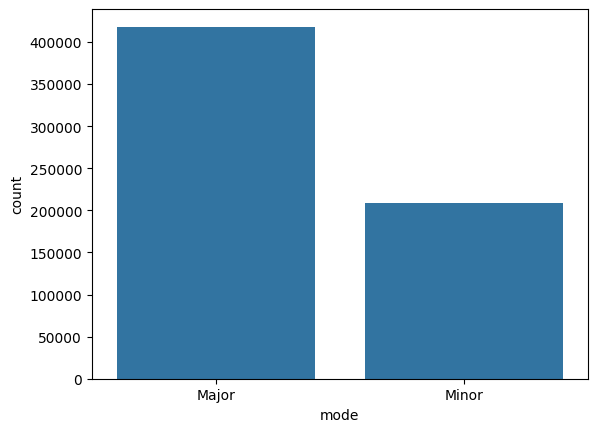

In [ ]:
# Mode distribution
sns.countplot(data=wdf, x="mode")
plt.show()

## Tempo feature

In [ ]:
# Possibles values
wdf.tempo.value_counts()

,count
tempo,
0.000,280
120.001,186
119.999,173
120.006,171
120.003,166
...,...
151.483,1
60.037,1
107.639,1


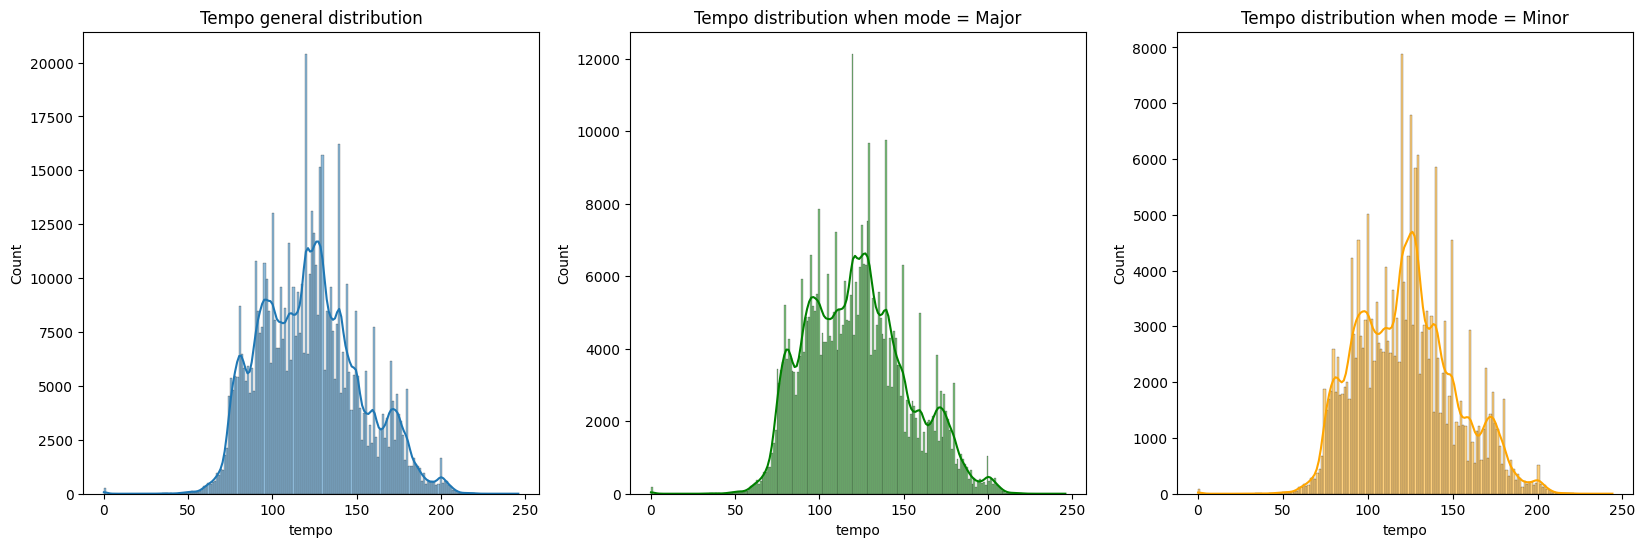

In [ ]:
# Histplot tempo
fig = plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title('Tempo general distribution')
sns.histplot(wdf['tempo'], bins=200, kde=True)

plt.subplot(1, 3, 2)
plt.title('Tempo distribution when mode = Major')
sns.histplot(wdf['tempo'][wdf['mode']=='Major'], kde=True, color='green')

plt.subplot(1, 3, 3)
plt.title('Tempo distribution when mode = Minor')
sns.histplot(wdf['tempo'][wdf['mode']=='Minor'], kde=True, color='orange')

plt.show()

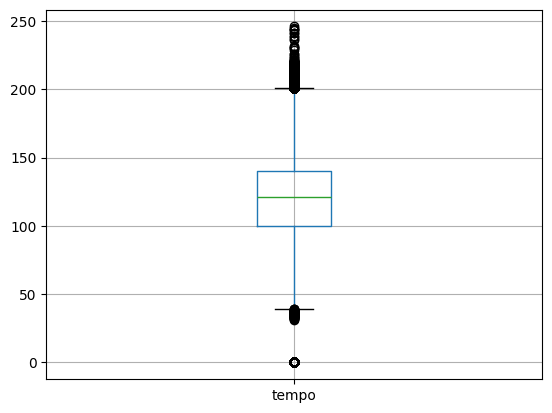

In [ ]:
# Tempo outliers
wdf[['tempo']].boxplot()
plt.show()

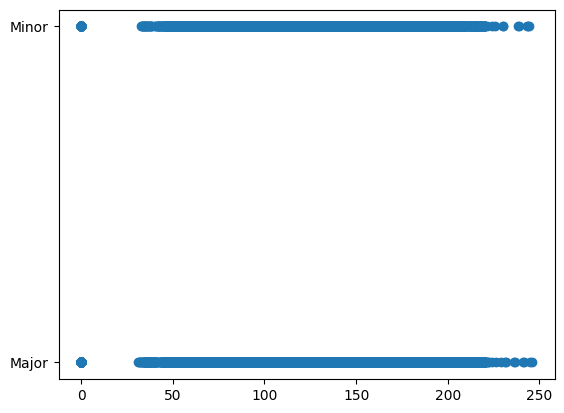

In [ ]:
# Plot tempo vs mode
plt.scatter(wdf['tempo'], wdf['mode'])
plt.show()

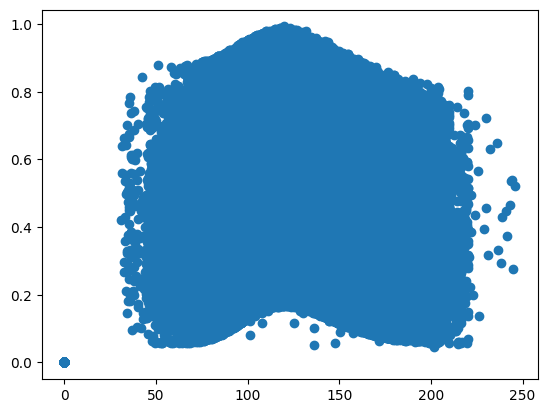

In [ ]:
# Scatter plot tempo vs danceability
plt.scatter(x=wdf['tempo'], y=wdf['danceability'])
plt.show()

In [ ]:
# Infos about tempo feature
print(wdf['tempo'].dtype)
print(wdf['tempo'].describe())
print((wdf['tempo'] < 40).sum())

float64
count    627094.000000
mean        122.450324
std          29.501811
min           0.000000
25%          99.906000
50%         121.249000
75%         140.298750
max         245.941000
Name: tempo, dtype: float64
358


In [ ]:
# Test of searching a song
songs = wdf[wdf['artists']=="Scorpions"]['name'].tolist()
print(songs)

['10 Light Years Away', '321', 'A Moment In A Million Years', 'Across the Universe', 'Alien Nation', 'Alien Nation - Edit', 'All Day And All of the Night', 'All for One', 'Always Somewhere', 'Always Somewhere (2015 - Remaster)', 'Always Somewhere - Live', 'Animal Magnetism', 'Another Piece Of Meat', 'Arizona', 'As Soon As The Good Times Roll', 'Backstage Queen', 'Bad Boys Running Wild', 'Bad Boys Running Wild - Live', 'Believe In Love', 'Big City Nights', 'Big City Nights (2015 - Remaster)', 'Big City Nights - Live', 'Big City Nights - MTV Unplugged', 'Blackout', 'Blackout - MTV Unplugged', 'Blood Too Hot', 'Borderline', 'Born To Touch Your Feelings - Remix', 'Born to Touch Your Feelings - MTV Unplugged', 'Born to Touch Your Feelings - Studio Edit', 'Call Of The Wild', 'Can You Feel It', "Can't Get Enough", "Can't Live Without You", "Can't Live Without You - MTV Unplugged", 'Catch Your Luck and Play', 'Catch Your Train', 'Children of the Revolution', 'Coming Home - Live', 'Crazy Ride',

In [ ]:
# Test to see if just one song per artist
wdf[wdf['name']=="Still Loving You"]

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
550593,0RdUX4WE0fO30VnlUbDVL6,Still Loving You,Comeblack,Scorpions,0.282,0.605,6,-4.916,Minor,0.0294,0.004700,0.001440,0.103,0.0783,103.929,403453.0,"Time, it needs time\n To win back your love ag..."
550595,1oMRkAdlRiuY4jfcUfjb6x,Still Loving You,NaN,Sonata Arctica,0.246,0.883,6,-5.238,Minor,0.0406,0.000096,0.013100,0.118,0.1460,85.595,271813.0,"Time, it needs time to remake your love again\..."
550596,3BPNTgZlNH6LBrzVTKCi0e,Still Loving You,NaN,Isgaard,0.206,0.443,9,-8.975,Minor,0.0381,0.709000,0.000093,0.696,0.3100,80.514,241534.0,Candle's burned out too fast\n Feelings lost i...


In [ ]:
# Tempo = 0
wdf[wdf['tempo']==0].shape

(280, 17)

In [ ]:
# Selection of songs where tempo > 0
wdf = wdf[wdf['tempo']>0]

In [ ]:
wdf.shape

(626814, 17)

## Other numerical features

In [ ]:
# Selection of numerical features
numcol = wdf.select_dtypes(float).columns.tolist()
numcol

['danceability',
 'energy',
 'loudness',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms']

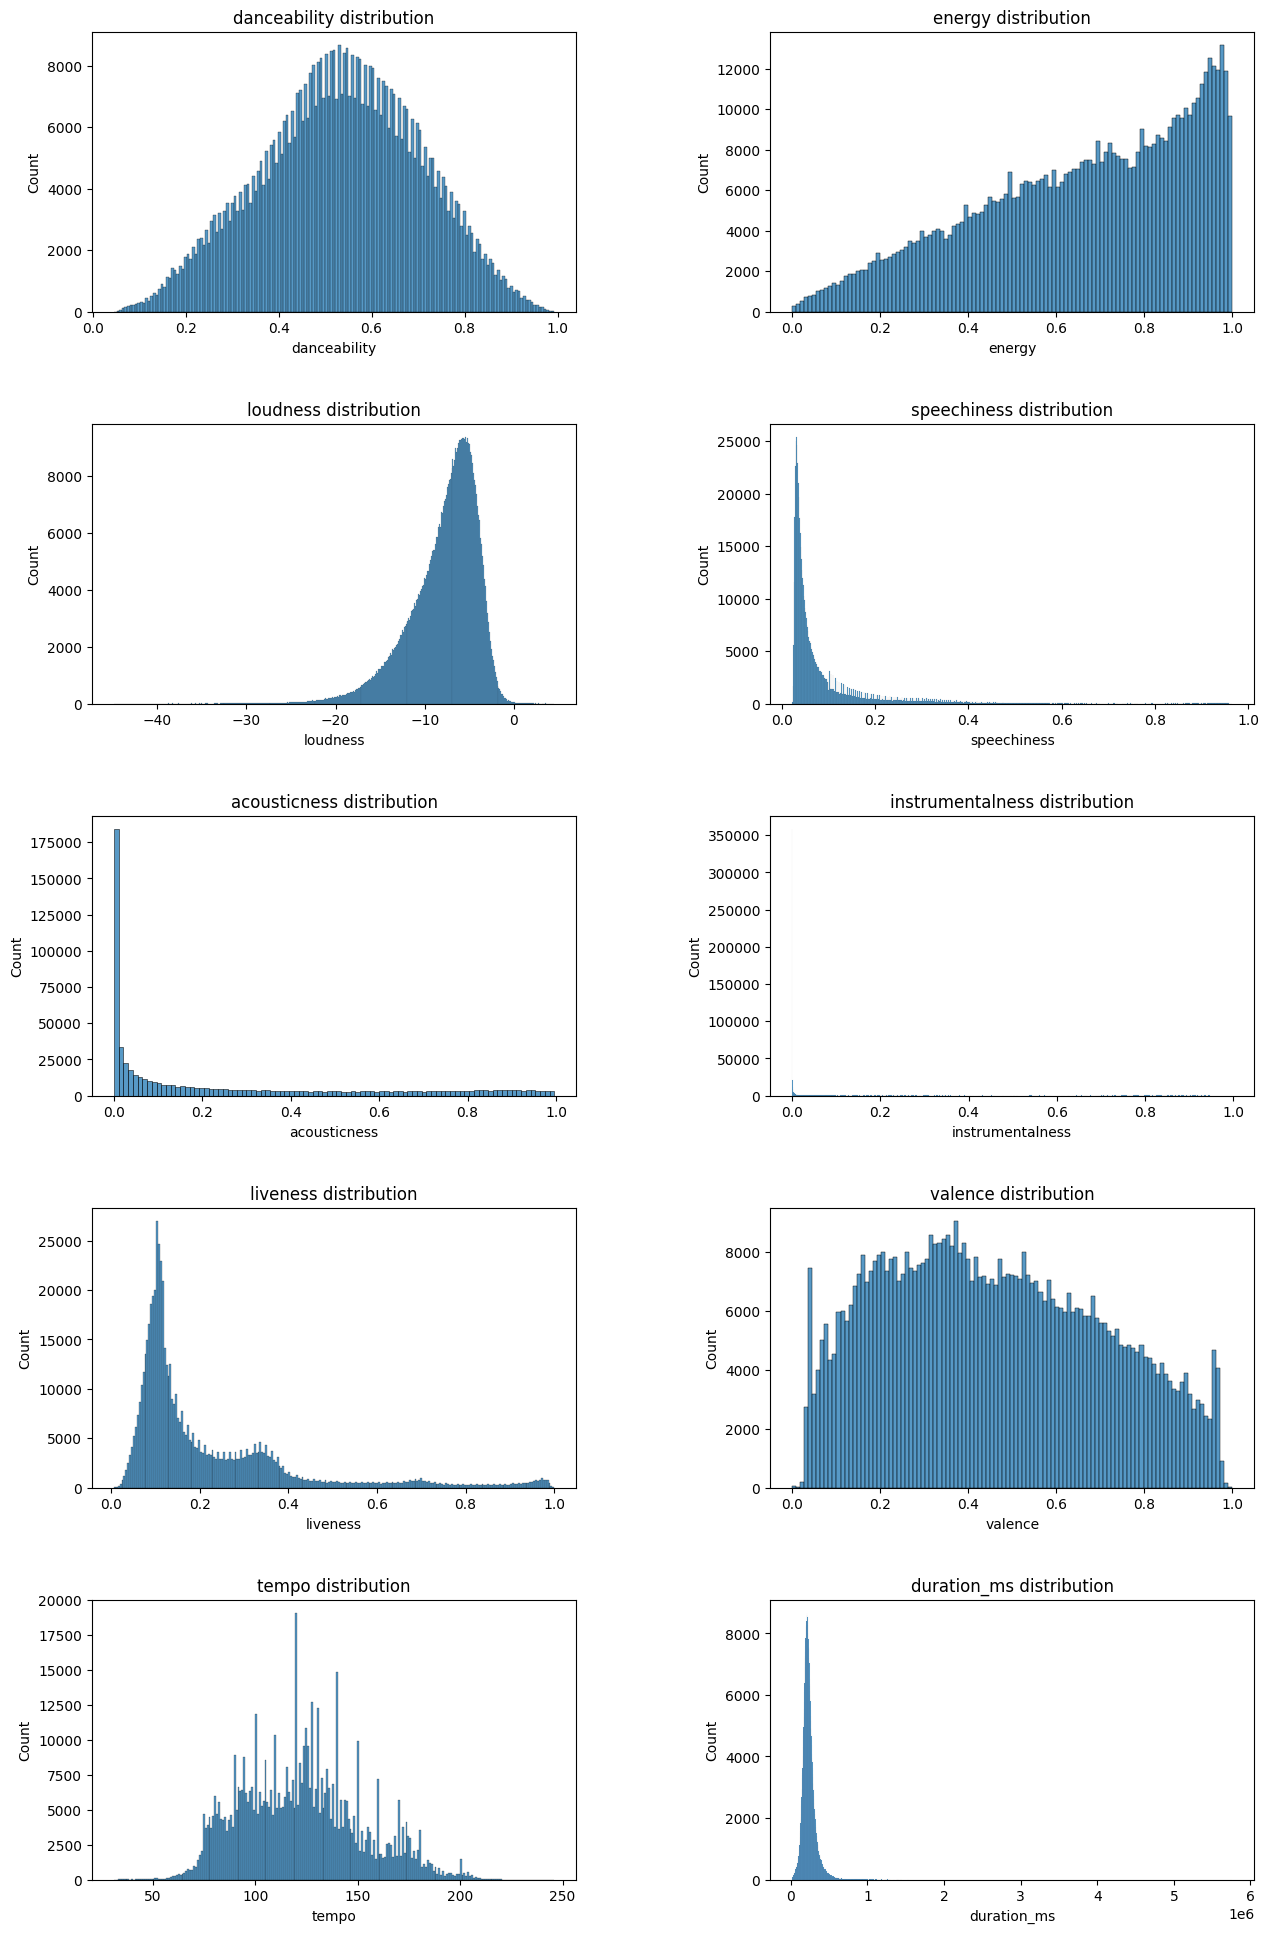

In [ ]:
# Distribution of numerical features
fig = plt.figure(figsize=(15, 24))

for i in range(len(numcol)):
    plt.subplot(5, int(len(numcol)/5), i+1)
    plt.title(f"{numcol[i]} distribution")
    sns.histplot(wdf[numcol[i]], bins='auto', kde=False, binrange=(wdf[numcol[i]].min(), wdf[numcol[i]].max()))
plt.subplots_adjust(wspace=0.4, hspace=0.4)


<Axes: xlabel='instrumentalness', ylabel='Count'>

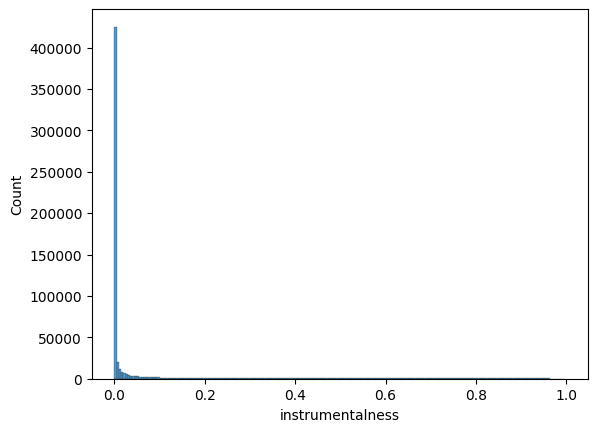

In [ ]:
sns.histplot(wdf['instrumentalness'], bins=200)

<Axes: xlabel='duration_ms', ylabel='Count'>

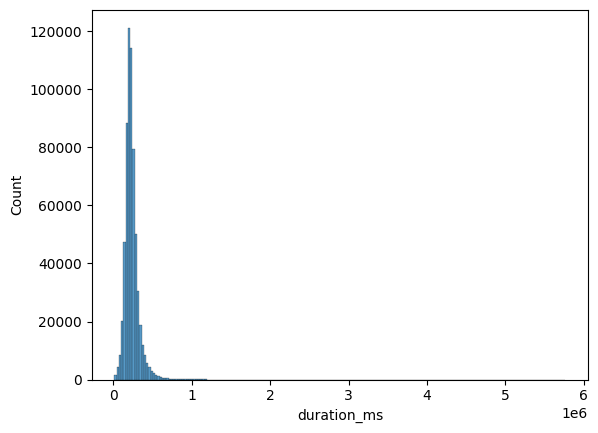

In [ ]:
sns.histplot(wdf['duration_ms'], bins=200)

## Categorical features

In [ ]:
# Selection of categorical features
catcol = wdf.select_dtypes("object").columns.tolist()
catcol

['id', 'name', 'album_name', 'artists', 'key', 'mode', 'lyrics']

In [ ]:
# Lyrics missing values
wdf['lyrics'].isnull().sum()

np.int64(0)

# Billboard dataset songs list

In [ ]:
# Import billboard_df
billboard_df = pd.read_csv('/content/drive/MyDrive/music_project/billboard_dataset.csv')

In [ ]:
billboard_df.head()

,Unnamed: 0,artists,name,spectro_filename,directory
0,0,Voices of Theory,Say It,Voices_of_Theory_-_Say_It.png,/home/turpindominique/.cache/kagglehub/dataset...
1,1,98,Because Of You,98_-_Because_Of_You.png,/home/turpindominique/.cache/kagglehub/dataset...
2,2,Jimmy Ray,Are You Jimmy Ray,Jimmy_Ray_-_Are_You_Jimmy_Ray.png,/home/turpindominique/.cache/kagglehub/dataset...
3,3,Nu Flavor,Heaven,Nu_Flavor_-_Heaven.png,/home/turpindominique/.cache/kagglehub/dataset...
4,4,KP Envyi,Swing My Way,KP_Envyi_-_Swing_My_Way.png,/home/turpindominique/.cache/kagglehub/dataset...


In [ ]:
billboard_df.shape

(5730, 5)

In [ ]:
# Duplicates
billboard_df[['name', 'artists']].duplicated().sum()

np.int64(0)

In [ ]:
# Drop duplicates
billboard_df.drop_duplicates(subset=['name', 'artists'], inplace=True)

In [ ]:
billboard_df

,Unnamed: 0,artists,name,spectro_filename,directory
0,0,Voices of Theory,Say It,Voices_of_Theory_-_Say_It.png,/home/turpindominique/.cache/kagglehub/dataset...
1,1,98,Because Of You,98_-_Because_Of_You.png,/home/turpindominique/.cache/kagglehub/dataset...
2,2,Jimmy Ray,Are You Jimmy Ray,Jimmy_Ray_-_Are_You_Jimmy_Ray.png,/home/turpindominique/.cache/kagglehub/dataset...
3,3,Nu Flavor,Heaven,Nu_Flavor_-_Heaven.png,/home/turpindominique/.cache/kagglehub/dataset...
4,4,KP Envyi,Swing My Way,KP_Envyi_-_Swing_My_Way.png,/home/turpindominique/.cache/kagglehub/dataset...
...,...,...,...,...,...
5725,5995,The Who,I Can See For Miles,The_Who_-_I_Can_See_For_Miles.png,/home/turpindominique/.cache/kagglehub/dataset...
5726,5996,Janis Ian,Societys Child,Janis_Ian_-_Societys_Child.png,/home/turpindominique/.cache/kagglehub/dataset...
5727,5997,The Association,Never My Love,The_Association_-_Never_My_Love.png,/home/turpindominique/.cache/kagglehub/dataset...
5728,5998,Jefferson Airplane,Somebody to Love,Jefferson_Airplane_-_Somebody_to_Love.png,/home/turpindominique/.cache/kagglehub/dataset...


In [ ]:
# Drop the column 'Unnamed: 0'
billboard_df.drop(columns = ['Unnamed: 0'], inplace=True)

In [ ]:
billboard_df

,artists,name,spectro_filename,directory
0,Voices of Theory,Say It,Voices_of_Theory_-_Say_It.png,/home/turpindominique/.cache/kagglehub/dataset...
1,98,Because Of You,98_-_Because_Of_You.png,/home/turpindominique/.cache/kagglehub/dataset...
2,Jimmy Ray,Are You Jimmy Ray,Jimmy_Ray_-_Are_You_Jimmy_Ray.png,/home/turpindominique/.cache/kagglehub/dataset...
3,Nu Flavor,Heaven,Nu_Flavor_-_Heaven.png,/home/turpindominique/.cache/kagglehub/dataset...
4,KP Envyi,Swing My Way,KP_Envyi_-_Swing_My_Way.png,/home/turpindominique/.cache/kagglehub/dataset...
...,...,...,...,...
5725,The Who,I Can See For Miles,The_Who_-_I_Can_See_For_Miles.png,/home/turpindominique/.cache/kagglehub/dataset...
5726,Janis Ian,Societys Child,Janis_Ian_-_Societys_Child.png,/home/turpindominique/.cache/kagglehub/dataset...
5727,The Association,Never My Love,The_Association_-_Never_My_Love.png,/home/turpindominique/.cache/kagglehub/dataset...
5728,Jefferson Airplane,Somebody to Love,Jefferson_Airplane_-_Somebody_to_Love.png,/home/turpindominique/.cache/kagglehub/dataset...


# Merge billboard_df and wdf

In [ ]:
# Selection of common songs of both billboard_df and wdf datasets
merge_df = pd.merge(wdf, billboard_df, how='inner', on =['name', 'artists'])

In [ ]:
merge_df.shape

(3088, 19)

In [ ]:
merge_df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory
0,0vywFmTIpTWGNEmuBHoU07,1 Thing,Single and Loving It,Amerie,0.612,0.961,10,-3.078,Minor,0.3330,0.1070,0.000042,0.0413,0.867,129.873,238760.0,"Whoo (uh)\n Whoo\n ♪\n Na-na-na-na-na, oh (uh-...",Amerie_-_1_Thing.png,/home/turpindominique/.cache/kagglehub/dataset...
1,4Sj8JZ9zZfl8HaOav5yTVq,1-800-273-8255,1-800-273-8255,Logic,0.622,0.593,5,-7.755,Minor,0.0414,0.5600,0.000000,0.1750,0.369,100.048,250200.0,I've been on the low\n I been taking my time\n...,Logic_-_1-800-273-8255.png,/home/turpindominique/.cache/kagglehub/dataset...
2,0B5KeB25moPkcQUnbDvj3t,100 Years,The Battle For Everything,Five For Fighting,0.643,0.569,7,-7.459,Major,0.0276,0.5440,0.000022,0.1780,0.275,120.507,244600.0,I'm 15 for a moment\n Caught in between ten an...,Five_For_Fighting_-_100_Years.png,/home/turpindominique/.cache/kagglehub/dataset...
3,0qgrrDnUUhyxpxbBznUnzg,18 and Life,Skid Row,Skid Row,0.466,0.648,1,-11.101,Minor,0.0280,0.0023,0.000015,0.1120,0.305,90.435,229960.0,"Ricky was a young boy, he had a heart of stone...",Skid_Row_-_18_and_Life.png,/home/turpindominique/.cache/kagglehub/dataset...
4,5KRRcT67VNIZUygEbMoIC1,1979,Mellon Collie And The Infinite Sadness,The Smashing Pumpkins,0.768,0.744,8,-11.267,Major,0.0338,0.0218,0.712000,0.0630,0.963,127.036,265893.0,"Shakedown, 1979\n ♪\n Cool kids never have the...",The_Smashing_Pumpkins_-_1979.png,/home/turpindominique/.cache/kagglehub/dataset...


### Some verifications

In [ ]:
# Selection of one artist in merge_df
merge_df[merge_df['artists']=='Voices of Theory']

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory
2154,5919i3Sp9U2IE5m7hhlgSw,Say It,Voices Of Theory,Voices of Theory,0.381,0.415,0,-10.298,Major,0.0691,0.675,0.0,0.0795,0.257,61.908,269467.0,Oh-ohoh-ohoh\n Oh-ohoh-ohohoh\n Oh-ohoh-ohoh\n...,Voices_of_Theory_-_Say_It.png,/home/turpindominique/.cache/kagglehub/dataset...


In [ ]:
# Selection of the same artist in wdf
wdf[wdf['artists']=='Voices of Theory']

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
93657,4Ob8lebX0NmLbjXZPtKmvp,Can We Go Back,Voices Of Theory,Voices of Theory,0.779,0.496,1,-6.333,Major,0.0263,0.234,0.000007,0.0833,0.769,89.176,238000.0,mmmmhmmm\n mmmmmmmm\n can we go... back\n mmmh...
195627,26aMt6xHTU9TXqNi513Gcf,Fly Away,Voices Of Theory,Voices of Theory,0.674,0.580,11,-7.519,Minor,0.0311,0.136,0.000021,0.0993,0.533,96.087,280133.0,i was knocking at the doors of your life\n but...
303823,3H96WeKpjyfBb6dRIvtgkV,Inside,Voices Of Theory,Voices of Theory,0.748,0.475,6,-7.764,Major,0.0353,0.377,0.000000,0.0668,0.673,88.957,242533.0,(Turn the lights low)\n I've been peepin you l...
501712,5919i3Sp9U2IE5m7hhlgSw,Say It,Voices Of Theory,Voices of Theory,0.381,0.415,0,-10.298,Major,0.0691,0.675,0.000000,0.0795,0.257,61.908,269467.0,Oh-ohoh-ohoh\n Oh-ohoh-ohohoh\n Oh-ohoh-ohoh\n...
676432,4G3HuXbtn7AwtW4aCIaMxx,Wherever You Go,Voices Of Theory,Voices of Theory,0.527,0.461,11,-7.570,Major,0.0252,0.687,0.000000,0.1870,0.261,107.836,339760.0,"Since you left me, my life ain't been the same..."


In [ ]:
merge_df.nunique()

,0
id,3088
name,2913
album_name,1198
artists,1420
danceability,751
energy,851
key,36
loudness,2712
mode,2
speechiness,846


In [ ]:
# Id duplicates on merge_df
merge_df['id'].duplicated().sum()

np.int64(0)

In [ ]:
# Id duplicates on wdf
wdf['id'].duplicated().sum()

np.int64(0)

# Work on lyrics

In [ ]:
# Instantiate sentiment analysis model
model = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest", batch_size=32)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# Text to line function
def text_to_lines(text):
    verses = [l.strip() for l in text.split('\n') if l.strip()]
    return verses

## Test on one song

In [ ]:
lines = text_to_lines(merge_df['lyrics'][0])

In [ ]:
len(lines)

85

In [ ]:
result = model(text_to_lines(merge_df['lyrics'][0]))

In [ ]:
result

[{'label': 'neutral', 'score': 0.8129460215568542},
 {'label': 'positive', 'score': 0.48605233430862427},
 {'label': 'neutral', 'score': 0.6304147839546204},
 {'label': 'neutral', 'score': 0.6788678169250488},
 {'label': 'neutral', 'score': 0.6788678169250488},
 {'label': 'neutral', 'score': 0.6788678169250488},
 {'label': 'neutral', 'score': 0.6883642077445984},
 {'label': 'neutral', 'score': 0.5982260704040527},
 {'label': 'neutral', 'score': 0.7032040357589722},
 {'label': 'neutral', 'score': 0.6645029187202454},
 {'label': 'negative', 'score': 0.47764191031455994},
 {'label': 'negative', 'score': 0.5381748676300049},
 {'label': 'neutral', 'score': 0.5010138154029846},
 {'label': 'negative', 'score': 0.7282225489616394},
 {'label': 'neutral', 'score': 0.7185689210891724},
 {'label': 'negative', 'score': 0.66219562292099},
 {'label': 'negative', 'score': 0.6490284204483032},
 {'label': 'positive', 'score': 0.5100955367088318},
 {'label': 'neutral', 'score': 0.5795885324478149},
 {'la

In [ ]:
result[6]['label']

'neutral'

## New feature "Positive lines"

In [ ]:
# positive_lines function
def positive_lines_rate(text):
    lines = text_to_lines(text)
    result = model(lines)
    n = 0
    m = 0
    o = 0
    for i in range(len(result)):
        n += (result[i]['label'] == 'positive')
        m += result[i]['label'] == 'negative'
        o += result[i]['label'] == 'neutral'
    return n, m , o, len(result), n/len(result)

In [ ]:
positive_lines_rate(merge_df['lyrics'][0])[4]

0.1411764705882353

In [ ]:
# Application of the positive_lines function on merge_df
merge_df['positive_rate'] = merge_df['lyrics'].apply(lambda x: positive_lines_rate(x)[4])

In [ ]:
# Verfication of the new column
merge_df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI
0,0vywFmTIpTWGNEmuBHoU07,1 Thing,Single and Loving It,Amerie,0.612,0.961,10,-3.078,0,0.3330,...,0.000042,0.0413,0.867,129.873,238760.0,"Whoo (uh)\n Whoo\n ♪\n Na-na-na-na-na, oh (uh-...",Amerie_-_1_Thing.png,/home/turpindominique/.cache/kagglehub/dataset...,0.141176,0.000340
1,4Sj8JZ9zZfl8HaOav5yTVq,1-800-273-8255,1-800-273-8255,Logic,0.622,0.593,5,-7.755,0,0.0414,...,0.000000,0.1750,0.369,100.048,250200.0,I've been on the low\n I been taking my time\n...,Logic_-_1-800-273-8255.png,/home/turpindominique/.cache/kagglehub/dataset...,0.282609,0.000112
2,0B5KeB25moPkcQUnbDvj3t,100 Years,The Battle For Everything,Five For Fighting,0.643,0.569,7,-7.459,1,0.0276,...,0.000022,0.1780,0.275,120.507,244600.0,I'm 15 for a moment\n Caught in between ten an...,Five_For_Fighting_-_100_Years.png,/home/turpindominique/.cache/kagglehub/dataset...,0.270833,0.000305
3,0qgrrDnUUhyxpxbBznUnzg,18 and Life,Skid Row,Skid Row,0.466,0.648,1,-11.101,0,0.0280,...,0.000015,0.1120,0.305,90.435,229960.0,"Ricky was a young boy, he had a heart of stone...",Skid_Row_-_18_and_Life.png,/home/turpindominique/.cache/kagglehub/dataset...,0.300000,0.000069
4,5KRRcT67VNIZUygEbMoIC1,1979,Mellon Collie And The Infinite Sadness,The Smashing Pumpkins,0.768,0.744,8,-11.267,1,0.0338,...,0.712000,0.0630,0.963,127.036,265893.0,"Shakedown, 1979\n ♪\n Cool kids never have the...",The_Smashing_Pumpkins_-_1979.png,/home/turpindominique/.cache/kagglehub/dataset...,0.090909,0.000097


In [ ]:
# numerical values for mode
merge_df['mode'] = merge_df['mode'].replace(['Major', 'Minor'], [1, 0])

In [ ]:
merge_df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI
0,0vywFmTIpTWGNEmuBHoU07,1 Thing,Single and Loving It,Amerie,0.612,0.961,10,-3.078,0,0.3330,...,0.000042,0.0413,0.867,129.873,238760.0,"Whoo (uh)\n Whoo\n ♪\n Na-na-na-na-na, oh (uh-...",Amerie_-_1_Thing.png,/home/turpindominique/.cache/kagglehub/dataset...,0.141176,0.000340
1,4Sj8JZ9zZfl8HaOav5yTVq,1-800-273-8255,1-800-273-8255,Logic,0.622,0.593,5,-7.755,0,0.0414,...,0.000000,0.1750,0.369,100.048,250200.0,I've been on the low\n I been taking my time\n...,Logic_-_1-800-273-8255.png,/home/turpindominique/.cache/kagglehub/dataset...,0.282609,0.000112
2,0B5KeB25moPkcQUnbDvj3t,100 Years,The Battle For Everything,Five For Fighting,0.643,0.569,7,-7.459,1,0.0276,...,0.000022,0.1780,0.275,120.507,244600.0,I'm 15 for a moment\n Caught in between ten an...,Five_For_Fighting_-_100_Years.png,/home/turpindominique/.cache/kagglehub/dataset...,0.270833,0.000305
3,0qgrrDnUUhyxpxbBznUnzg,18 and Life,Skid Row,Skid Row,0.466,0.648,1,-11.101,0,0.0280,...,0.000015,0.1120,0.305,90.435,229960.0,"Ricky was a young boy, he had a heart of stone...",Skid_Row_-_18_and_Life.png,/home/turpindominique/.cache/kagglehub/dataset...,0.300000,0.000069
4,5KRRcT67VNIZUygEbMoIC1,1979,Mellon Collie And The Infinite Sadness,The Smashing Pumpkins,0.768,0.744,8,-11.267,1,0.0338,...,0.712000,0.0630,0.963,127.036,265893.0,"Shakedown, 1979\n ♪\n Cool kids never have the...",The_Smashing_Pumpkins_-_1979.png,/home/turpindominique/.cache/kagglehub/dataset...,0.090909,0.000097


<Axes: xlabel='positive_rate', ylabel='Count'>

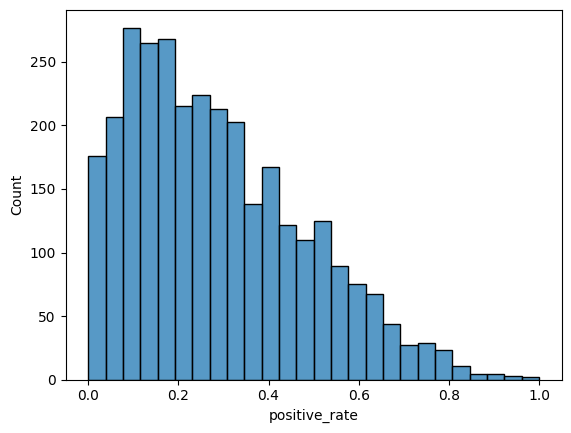

In [ ]:
# positive_rate distribution
sns.histplot(merge_df['positive_rate'])

## Feature correlation test

<Axes: >

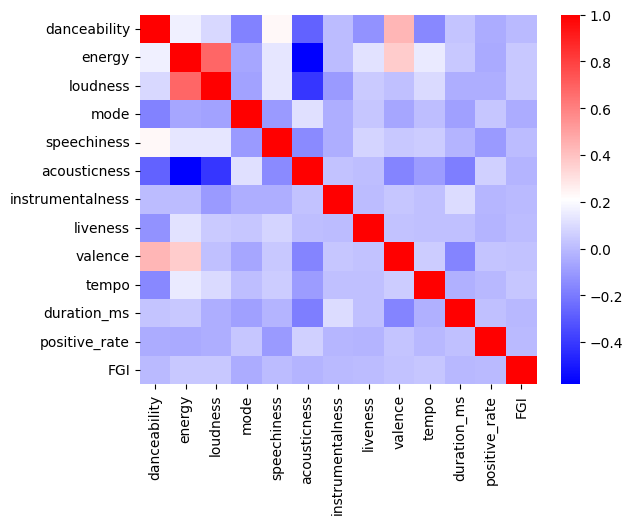

In [ ]:
# Heatmap of pairwise correlation
correlation_matrix = merge_df.select_dtypes('number').corr()
column_names = correlation_matrix.columns
sns.heatmap(correlation_matrix, xticklabels=column_names, yticklabels=column_names,cmap= "bwr")

# Preprocessing

In [ ]:
# Selection of the numerical columns
merge_df_num = merge_df.select_dtypes('number')
merge_df_num.head()

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,positive_rate,FGI
0,0.612,0.961,-3.078,0,0.3330,0.1070,0.000042,0.0413,0.867,129.873,238760.0,0.141176,0.000340
1,0.622,0.593,-7.755,0,0.0414,0.5600,0.000000,0.1750,0.369,100.048,250200.0,0.282609,0.000112
2,0.643,0.569,-7.459,1,0.0276,0.5440,0.000022,0.1780,0.275,120.507,244600.0,0.270833,0.000305
3,0.466,0.648,-11.101,0,0.0280,0.0023,0.000015,0.1120,0.305,90.435,229960.0,0.300000,0.000069
4,0.768,0.744,-11.267,1,0.0338,0.0218,0.712000,0.0630,0.963,127.036,265893.0,0.090909,0.000097


In [ ]:
# Definition of X and y
X = merge_df_num.drop(columns='positive_rate')
y = merge_df_num['positive_rate']

In [ ]:
X.head()

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,FGI
0,0.612,0.961,-3.078,0,0.3330,0.1070,0.000042,0.0413,0.867,129.873,238760.0,0.000340
1,0.622,0.593,-7.755,0,0.0414,0.5600,0.000000,0.1750,0.369,100.048,250200.0,0.000112
2,0.643,0.569,-7.459,1,0.0276,0.5440,0.000022,0.1780,0.275,120.507,244600.0,0.000305
3,0.466,0.648,-11.101,0,0.0280,0.0023,0.000015,0.1120,0.305,90.435,229960.0,0.000069
4,0.768,0.744,-11.267,1,0.0338,0.0218,0.712000,0.0630,0.963,127.036,265893.0,0.000097


In [ ]:
y.head()

,positive_rate
0,0.141176
1,0.282609
2,0.270833
3,0.300000
4,0.090909


In [ ]:
# Instantiate robust scaler
rb_scaler = RobustScaler()

# Configure pandas exit
rb_scaler.set_output(transform='pandas')

# Fit_transform
X_scaled = rb_scaler.fit_transform(X)

In [ ]:
X_scaled.head()

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,FGI
0,-0.107905,1.079038,0.941581,-1.0,8.841390,-0.125523,0.180791,-0.622272,0.662461,0.287708,0.123447,0.249372
1,-0.057716,-0.185567,-0.048365,-1.0,0.031722,1.138075,-0.013163,0.383747,-0.594322,-0.545712,0.299537,-0.153534
2,0.047679,-0.268041,0.014287,0.0,-0.385196,1.093445,0.087767,0.406321,-0.831546,0.025988,0.213339,0.187411
3,-0.840652,0.003436,-0.756588,-1.0,-0.373112,-0.417573,0.056140,-0.090293,-0.755836,-0.814335,-0.012006,-0.229213
4,0.675031,0.333333,-0.791724,0.0,-0.197885,-0.363180,3311.614744,-0.458992,0.904732,0.208432,0.541090,-0.179305


# Train test split

In [ ]:
X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Baseline : régression linéaire

In [ ]:
# Instantiate the model
baseline = LinearRegression()

# Cross validate the model
cv_results = cross_validate(baseline, X_scaled_train, y_train, cv=5)


In [ ]:
cv_results['test_score'].mean()

np.float64(0.010015816867666994)

As expected, low score

# New model : GradientBoostingRegressor

In [ ]:
gb_model = GradientBoostingRegressor()

In [ ]:
cv_results = cross_validate(gb_model, X_scaled_train, y_train, cv=5)

In [ ]:
cv_results['test_score'].mean()

np.float64(-0.01926807550912648)

As expected, low score too

# New model : DummyRegressor

In [ ]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
cv_results = cross_validate(dummy, X_scaled_train, y_train, cv=5)
cv_results['test_score'].mean()

np.float64(-0.0016702297819620072)

I will have to calculate the FGI.

# Classification of merge-df

## New feature : FGI

In [ ]:
# Definition of FGI column
merge_df['FGI'] = merge_df['positive_rate']/(((merge_df['tempo']-150) ** 2 - merge_df['mode']))

In [ ]:
merge_df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI
0,0vywFmTIpTWGNEmuBHoU07,1 Thing,Single and Loving It,Amerie,0.612,0.961,10,-3.078,0,0.3330,...,0.000042,0.0413,0.867,129.873,238760.0,"Whoo (uh)\n Whoo\n ♪\n Na-na-na-na-na, oh (uh-...",Amerie_-_1_Thing.png,/home/turpindominique/.cache/kagglehub/dataset...,0.137931,0.000340
1,4Sj8JZ9zZfl8HaOav5yTVq,1-800-273-8255,1-800-273-8255,Logic,0.622,0.593,5,-7.755,0,0.0414,...,0.000000,0.1750,0.369,100.048,250200.0,I've been on the low\n I been taking my time\n...,Logic_-_1-800-273-8255.png,/home/turpindominique/.cache/kagglehub/dataset...,0.279570,0.000112
2,0B5KeB25moPkcQUnbDvj3t,100 Years,The Battle For Everything,Five For Fighting,0.643,0.569,7,-7.459,1,0.0276,...,0.000022,0.1780,0.275,120.507,244600.0,I'm 15 for a moment\n Caught in between ten an...,Five_For_Fighting_-_100_Years.png,/home/turpindominique/.cache/kagglehub/dataset...,0.265306,0.000305
3,0qgrrDnUUhyxpxbBznUnzg,18 and Life,Skid Row,Skid Row,0.466,0.648,1,-11.101,0,0.0280,...,0.000015,0.1120,0.305,90.435,229960.0,"Ricky was a young boy, he had a heart of stone...",Skid_Row_-_18_and_Life.png,/home/turpindominique/.cache/kagglehub/dataset...,0.245283,0.000069
4,5KRRcT67VNIZUygEbMoIC1,1979,Mellon Collie And The Infinite Sadness,The Smashing Pumpkins,0.768,0.744,8,-11.267,1,0.0338,...,0.712000,0.0630,0.963,127.036,265893.0,"Shakedown, 1979\n ♪\n Cool kids never have the...",The_Smashing_Pumpkins_-_1979.png,/home/turpindominique/.cache/kagglehub/dataset...,0.051282,0.000097


In [ ]:
# Descending classification
classification = merge_df.sort_values('FGI', ascending=False)
classification.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI
2888,29CHV81UPFbNtQyTvfYt1Q,What the Hell,Single and Loving It,Avril Lavigne,0.571,0.932,6,-3.680,0,0.0576,...,0.009390,0.117,0.864,150.014,220627.0,You say that I'm messing with your head\n All ...,Avril_Lavigne_-_What_the_Hell.png,/home/turpindominique/.cache/kagglehub/dataset...,0.188679,962.649211
239,0puf9yIluy9W0vpMEUoAnN,Bang Bang,Sweet Talker (Deluxe Version),Jessie J,0.706,0.786,0,-3.417,0,0.0909,...,0.000000,0.380,0.749,150.035,199387.0,She got a body like an hourglass\n But I can g...,Jessie_J_-_Bang_Bang.png,/home/turpindominique/.cache/kagglehub/dataset...,0.353846,288.854003
2774,1ZntV75KmB90f7MZVLPDzO,Uma Thurman,Helloween Party,Fall Out Boy,0.623,0.961,4,-2.616,0,0.0869,...,0.000171,0.264,0.668,149.963,211573.0,"I can move mountains\n I can work a miracle, w...",Fall_Out_Boy_-_Uma_Thurman.png,/home/turpindominique/.cache/kagglehub/dataset...,0.352941,257.809479
2546,4j2Z0fivH9kDUhqG69Z3Aa,The Great Escape,Boys Like Girls,Boys Like Girls,0.423,0.940,1,-4.012,0,0.0635,...,0.000000,0.178,0.505,149.934,206520.0,Paper bags and plastic hearts\n All our belong...,Boys_Like_Girls_-_The_Great_Escape.png,/home/turpindominique/.cache/kagglehub/dataset...,0.326087,74.859265
2029,4knL4iPxPOZjQzTUlELGSY,Rake It Up,I Still Am,Yo Gotti,0.910,0.444,1,-8.126,0,0.3440,...,0.000000,0.137,0.530,149.953,276333.0,"Ear Drummers (30, you a fool for this one)\n A...",Yo_Gotti_-_Rake_It_Up.png,/home/turpindominique/.cache/kagglehub/dataset...,0.098039,44.381718


In [ ]:
# New column 'number'
classification['number'] = range(1, len(classification)+1)

In [ ]:
classification.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI,number
2888,29CHV81UPFbNtQyTvfYt1Q,What the Hell,Single and Loving It,Avril Lavigne,0.571,0.932,6,-3.680,0,0.0576,...,0.117,0.864,150.014,220627.0,You say that I'm messing with your head\n All ...,Avril_Lavigne_-_What_the_Hell.png,/home/turpindominique/.cache/kagglehub/dataset...,0.166667,850.340136,1
239,0puf9yIluy9W0vpMEUoAnN,Bang Bang,Sweet Talker (Deluxe Version),Jessie J,0.706,0.786,0,-3.417,0,0.0909,...,0.380,0.749,150.035,199387.0,She got a body like an hourglass\n But I can g...,Jessie_J_-_Bang_Bang.png,/home/turpindominique/.cache/kagglehub/dataset...,0.348485,284.477427,2
2774,1ZntV75KmB90f7MZVLPDzO,Uma Thurman,Helloween Party,Fall Out Boy,0.623,0.961,4,-2.616,0,0.0869,...,0.264,0.668,149.963,211573.0,"I can move mountains\n I can work a miracle, w...",Fall_Out_Boy_-_Uma_Thurman.png,/home/turpindominique/.cache/kagglehub/dataset...,0.346154,252.851604,3
2546,4j2Z0fivH9kDUhqG69Z3Aa,The Great Escape,Boys Like Girls,Boys Like Girls,0.423,0.940,1,-4.012,0,0.0635,...,0.178,0.505,149.934,206520.0,Paper bags and plastic hearts\n All our belong...,Boys_Like_Girls_-_The_Great_Escape.png,/home/turpindominique/.cache/kagglehub/dataset...,0.319149,73.266514,4
2029,4knL4iPxPOZjQzTUlELGSY,Rake It Up,I Still Am,Yo Gotti,0.910,0.444,1,-8.126,0,0.3440,...,0.137,0.530,149.953,276333.0,"Ear Drummers (30, you a fool for this one)\n A...",Yo_Gotti_-_Rake_It_Up.png,/home/turpindominique/.cache/kagglehub/dataset...,0.097087,43.950828,5


# Test on Queen song

In [ ]:
# Songs of Queen
classification[classification['artists']=='Queen']

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,duration_ms,lyrics,spectro_filename,directory,positive_rate,FGI,number
350,3z8h0TU7ReDPLIbEnYhWZb,Bohemian Rhapsody,Bohemian Rhapsody (The Original Soundtrack),Queen,0.390,0.397,0,-9.963,0,0.0513,...,0.2070,0.246,144.031,354947.0,Is this the real life? Is this just fantasy?\n...,Queen_-_Bohemian_Rhapsody.png,/home/turpindominique/.cache/kagglehub/dataset...,0.147541,0.004141,240
2313,3CCxL8R4wxfrGKqAmprgQi,Somebody To Love,NaN,Queen,0.493,0.584,8,-11.008,1,0.0573,...,0.1140,0.361,110.101,295960.0,Can\n Anybody find me\n Somebody to love?\n Oo...,Queen_-_Somebody_To_Love.png,/home/turpindominique/.cache/kagglehub/dataset...,0.430380,0.000271,1303
1399,1KPMTL3BRLBWrNY8fveVy6,Killer Queen,NaN,Queen,0.562,0.494,10,-11.523,1,0.0421,...,0.0685,0.579,117.129,180027.0,"(This is called ""Killer Queen"")\n She keeps th...",Queen_-_Killer_Queen.png,/home/turpindominique/.cache/kagglehub/dataset...,0.166667,0.000154,1720
2865,0a9sd6MEXZXIPHk0fAxpZ4,We Will Rock You,NaN,Queen,0.686,0.384,11,-10.424,0,0.0719,...,0.1530,0.544,81.412,121973.0,"Buddy, you're a boy, make a big noise\n Playin...",Queen_-_We_Will_Rock_You.png,/home/turpindominique/.cache/kagglehub/dataset...,0.476190,0.000101,2056
166,291RmMazWAmDitFuD6NJCv,Another One Bites The Dust,NaN,Queen,0.926,0.366,5,-13.159,0,0.1220,...,0.1190,0.784,109.884,215867.0,Let's go!\n Steve walks warily down the street...,Queen_-_Another_One_Bites_The_Dust.png,/home/turpindominique/.cache/kagglehub/dataset...,0.156250,0.000097,2098
2856,0z0gqCUMdkydEttZmKze1h,We Are The Champions,NaN,Queen,0.257,0.455,7,-9.259,0,0.0385,...,0.1040,0.198,58.540,180627.0,I've paid my dues time after time\n I've done ...,Queen_-_We_Are_The_Champions.png,/home/turpindominique/.cache/kagglehub/dataset...,0.555556,0.000066,2406
546,1F9NVicWfNQA5ki8WmEtk8,Crazy Little Thing Called Love,NaN,Queen,0.626,0.762,7.0,-6.846,1,0.0432,...,0.3250,0.766,76.793,163342.0,This thing called love\n I just can't handle i...,Queen_-_Crazy_Little_Thing_Called_Love.png,/home/turpindominique/.cache/kagglehub/dataset...,0.314815,0.000059,2471


In [ ]:
# Selection of the song "Don't Stop Me Now"
test_df = wdf[(wdf['name']=="Don't Stop Me Now") & (wdf['artists']=='Queen')]

In [ ]:
test_df['lyrics']

,lyrics
153676,Tonight\n I'm gonna have myself a real good ti...


In [ ]:
# Aplication of positive_lines_rate
result = positive_lines_rate(test_df['lyrics'].iloc[0])[4]/(((test_df['tempo'].iloc[0]-150) ** 2 - test_df['mode'].replace({'Major': 1, 'Minor': 0}).iloc[0]))

/tmp/ipykernel_791/1913775680.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = positive_lines_rate(test_df['lyrics'].iloc[0])[4]/(((test_df['tempo'].iloc[0]-150) ** 2 - test_df['mode'].replace({'Major': 1, 'Minor': 0}).iloc[0]))


In [ ]:
result

np.float64(0.010715285903031524)

In [ ]:
# Classification of the song
str(classification[(((result-0.0001)<=classification['FGI']) & (classification['FGI'] <= float(result+0.0001)))]['number'].iloc[0])

TypeError: unsupported operand type(s) for -: 'list' and 'float'